# Emergency Triage Code Prediction from Vital-Sign **Time Windows**

Instead of classifying a single snapshot, we summarize a **short window of consecutive vital-sign readings** and predict the patient's **triage code** on the Italian **5-level numeric scale**. Summary statistics over the window capture both *level* and *variability/trend* — in particular the least-squares slope, which no single instant can provide.

**Italian 5-level triage scale** (national guidelines). Lower number = more urgent:

| Code | Colour | Meaning | Target time |
|---|---|---|---|
| **1** | Red | Emergency (life-threatening) | immediate |
| **2** | Orange | Very urgent | ~15 min |
| **3** | Blue | Deferrable urgency | ~60 min |
| **4** | Green | Minor urgency | ~120 min |
| **5** | White | Non-urgent | ~240 min |

Internally the classes are 0-indexed (`index = code − 1`): `index 0 → Code 1 (Red) … index 4 → Code 5 (White)`.

**Window-size study.** Rather than committing to a single window length, the notebook trains the same MLP for **several window sizes**, compares the main indexes (accuracy, macro precision/recall/F1, Code-1 recall, footprint) **before the Contiki translation** (float Keras model) and **after it** (the C model generated by emlearn, exactly what the nRF52840 executes), and only then emits the deployment artifacts for the chosen window.

Note that the window length does **not** change the architecture here: the time axis is collapsed by a fixed set of summary statistics before the network, so every window size feeds the same 30-value input vector. The sweep therefore answers *"over how long should the statistics be aggregated"*, not *"which architecture is best"*.

## 1. Setup

In [ ]:
!pip install tensorflow[and-cuda] vitaldb scikit-learn seaborn

In [ ]:
import os
import warnings
warnings.filterwarnings('ignore')

import json
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_recall_fscore_support)
from sklearn.utils.class_weight import compute_class_weight

import vitaldb

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
sns.set_theme(style='whitegrid')
print('TensorFlow', tf.__version__)  # Sanity check

# Let TensorFlow use the GPU memory
for _gpu in tf.config.list_physical_devices('GPU'):
    try:
        tf.config.experimental.set_memory_growth(_gpu, True)
    except Exception:
        pass
print('GPUs:', tf.config.list_physical_devices('GPU') or 'none (CPU run)')

TensorFlow 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Data Download

**Six vital signs** feed the model: `HR` (bpm), `SBP`/`DBP` (mmHg), `RR` (breaths/min), `SpO2` (%), `Temp` (°C).

### Data sources
- **VitalDB (real).** The [VitalDB open dataset](https://vitaldb.net) holds intraoperative recordings from 6,388 surgical cases. We pull the six numeric tracks through the `vitaldb` API.

### Labels for the real data — a NEWS2 proxy
VitalDB has **no triage label**, so for the real-data path we derive one: a simplified **NEWS2** (thanks Sara and Giulia) early-warning score is computed per window and its aggregate is binned into the 5 triage levels (higher score → more urgent → lower code). 

### Window sizes under test
`WINDOW_SIZES = [10, 20, 30, 45, 60]` readings. At `SAMPLING_INTERVAL = 1 s` they span **10–60 s** of real time (the int8 window buffer stays tiny: `W × 6` bytes → 60–360 B). 

On the MAX30102 the sampling frequency is 100 Hz but it is referred to the raw PPG waveform ADC rate. HR/SpO2 are computed from a window of that signal and are sent in output at 1 Hz. This is why we choose to select `SAMPLING_INTERVAL = 1 s`.

To avoid re-downloading from the API once per window size, each case is fetched **once**, gap-filled, cached to disk, and then sliced locally into windows of every size.

In [ ]:
SAMPLING_INTERVAL = 1

WINDOW_SIZES    = [10, 20, 30, 45, 60]   # readings per window (= seconds at 1 Hz)
BASELINE_WINDOW = 30                     # used by the EDA plots and as default deployment choice

FEATURES    = ['HR', 'SBP', 'DBP', 'RR', 'SpO2', 'Temp']
CODE_LABELS = ['1 - Red', '2 - Orange', '3 - Blue', '4 - Green', '5 - White']  # index 0..4
CODE_COLORS = ['#d64545', '#e08a1e', '#3a7bd5', '#2e9e5b', '#9e9e9e']

USE_CLASS_WEIGHTS = True   # Code 1 (Red) is rare -> balanced loss weights so it cannot be ignored
MAX_CASES         = None   # e.g. 300 for a quick smoke test of the whole notebook

In [ ]:
# --- Proxy labels for the REAL data: NEWS2 early-warning score ---
# VitalDB has no triage label, so we score each window and bin the aggregate into
# the 5 levels. Higher aggregate -> more urgent -> lower code number -> lower index.
    
def label_from_window_batch(X, chunk=500_000):
    '''Vectorized + chunked: plain np.median (data is NaN-free by construction),
    processed in blocks to keep peak temporary memory bounded.'''
    out = np.empty(len(X), dtype=int)
    for i in range(0, len(X), chunk):
        m = np.median(X[i:i + chunk], axis=1)        # (chunk, 6)
        hr, sbp, rr, spo2, temp = m[:, 0], m[:, 1], m[:, 3], m[:, 4], m[:, 5]

        s_rr   = np.select([rr <= 8,  rr <= 11, rr <= 20, rr <= 24], [3, 1, 0, 2], default=3)
        s_spo2 = np.select([spo2 >= 96, spo2 >= 94, spo2 >= 92],      [0, 1, 2],    default=3)
        s_sbp  = np.select([sbp <= 90, sbp <= 100, sbp <= 110, sbp <= 219], [3, 2, 1, 0], default=3)
        s_hr   = np.select([hr <= 40, hr <= 50, hr <= 90, hr <= 110, hr <= 130], [3, 1, 0, 1, 2], default=3)
        s_temp = np.select([temp <= 35, temp <= 36, temp <= 38, temp <= 39], [3, 1, 0, 1], default=2)

        agg = s_rr + s_spo2 + s_sbp + s_hr + s_temp
        out[i:i + chunk] = np.select([agg >= 9, agg >= 7, agg >= 5, agg >= 2], [0, 1, 2, 3], default=4)
    return out

In [ ]:
# --- Load the VitalDB open dataset ONCE, cache the per-case series, slice locally ---

TRACK_MAP = {
    'HR':   'Solar8000/HR',
    'SBP':  'Solar8000/ART_SBP',    
    'DBP':  'Solar8000/ART_DBP',    
    'RR':   'Solar8000/RR_CO2',     
    'SpO2': 'Solar8000/PLETH_SPO2',
    'Temp': 'Solar8000/BT',
}

FEATURE_DEFAULTS = np.array([80, 120, 78, 16, 97, 36.8], dtype=float)  # HR,SBP,DBP,RR,SpO2,Temp

SERIES_CACHE = 'vitaldb_series.npz'

def _ffill_bfill(a):
    '''Fill NaNs column-wise: back-fill leading gaps, forward-fill the rest.'''
    a = a.astype(float).copy()
    for j in range(a.shape[1]):
        col = a[:, j]
        good = np.where(~np.isnan(col))[0]
        if len(good) == 0:
            continue
        col[:good[0]] = col[good[0]]
        for i in range(good[0] + 1, len(col)):
            if np.isnan(col[i]):
                col[i] = col[i - 1]
        a[:, j] = col
    return a


def load_vitaldb_series(interval=SAMPLING_INTERVAL, max_cases=MAX_CASES, cache=SERIES_CACHE):
    '''Read every case that has the tracks and keep its FULL gap-filled series.
    Missing values are forward/back-filled; anything still missing (a track absent
    for a whole case) is imputed with a physiological default, so no data is ever
    discarded. The result is cached so the window-size sweep never re-downloads.'''
    if cache and os.path.exists(cache):
        d = np.load(cache)
        series = [d[k] for k in sorted(d.files, key=lambda s: int(s.split('_')[1]))]
        print(f'Loaded {len(series)} cached case series from {cache}')
        return series

    tracks  = [TRACK_MAP[f] for f in FEATURES]
    caseids = vitaldb.find_cases(tracks)
    if max_cases is not None:
        caseids = caseids[:max_cases]

    series, min_len = [], min(WINDOW_SIZES)
    for k, cid in enumerate(caseids, 1):
        try:
            arr = vitaldb.load_case(cid, tracks, interval=interval)
        except Exception:
            continue
        if arr is None or len(arr) < min_len:
            continue
        filled = _ffill_bfill(np.asarray(arr, dtype=float))
        filled = np.where(np.isnan(filled), FEATURE_DEFAULTS, filled)
        series.append(filled.astype(np.float32))
        if k % 250 == 0:
            print(f'  ...{k}/{len(caseids)} cases scanned, {len(series)} kept')

    if cache and len(series):
        np.savez_compressed(cache, **{f'case_{i}': s for i, s in enumerate(series)})
        print(f'Cached {len(series)} case series to {cache}')
    return series


def make_windows(series, window, stride=None):
    '''Slice every cached case into (window, features) segments; label everything at once.'''
    stride = max(1, window // 2) if stride is None else stride
    X_list = []
    for s_arr in series:
        if len(s_arr) < window:
            continue
        for s in range(0, len(s_arr) - window + 1, stride):
            X_list.append(s_arr[s:s + window])
    X = np.asarray(X_list, dtype=np.float32)
    y = label_from_window_batch(X)
    return X, y

In [ ]:
series = load_vitaldb_series()
if len(series) == 0:
    raise RuntimeError('No usable VitalDB cases — check internet')

# Baseline dataset (used by the EDA below; the sweep re-slices the series for every size)
WINDOW = BASELINE_WINDOW
STRIDE = WINDOW // 2
X, y = make_windows(series, WINDOW, STRIDE)

print('X shape     :', X.shape, '(windows, timesteps, features)')
dist = pd.Series(np.bincount(y, minlength=len(CODE_LABELS)), index=CODE_LABELS)
print('\nClass distribution:')
print(dist)

Loaded 3581 cached case series from vitaldb_series.npz
X shape     : (3304331, 30, 6) (windows, timesteps, features)

Class distribution:
1 - Red        162731
2 - Orange     119943
3 - Blue       316745
4 - Green     1331259
5 - White     1373653
dtype: int64


## 3. Exploratory Data Analysis

Plots use the baseline `WINDOW = 30`; the sweep below re-slices the cached series for every size.

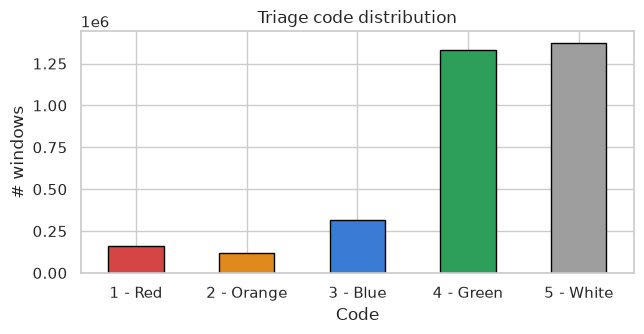

In [ ]:
# Class distribution
ax = dist.plot(kind='bar', color=CODE_COLORS, edgecolor='black', figsize=(6.5, 3.5))
ax.set_title('Triage code distribution'); ax.set_xlabel('Code'); ax.set_ylabel('# windows')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

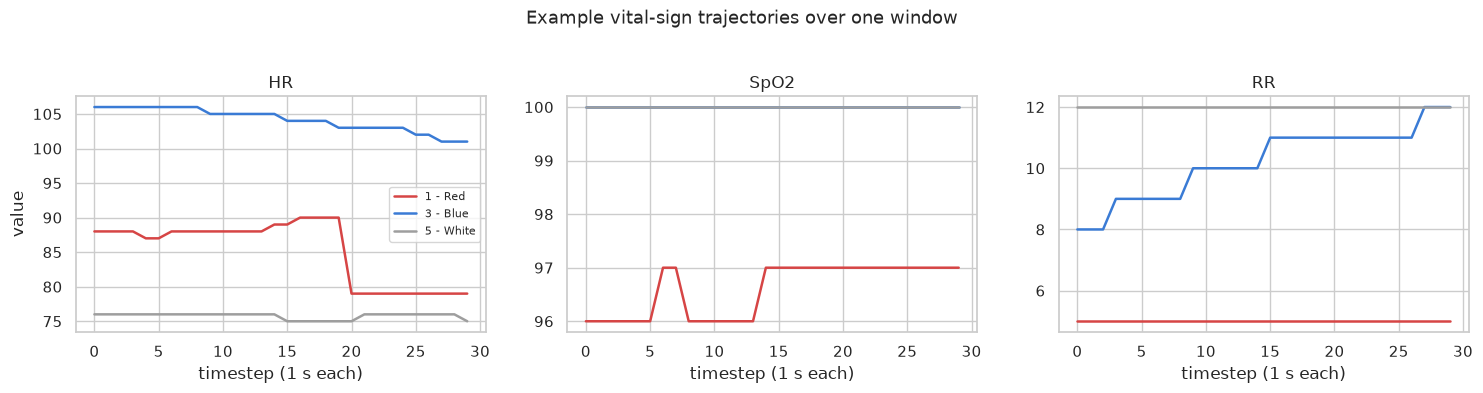

In [ ]:
# One example window per class for three key vitals — shows the TEMPORAL structure
show_codes = [0, 2, 4]   # Red, Blue, White
show_feats = ['HR', 'SpO2', 'RR']
# grab the first window of each shown class
examples = {c: X[np.where(y == c)[0][0]] for c in show_codes}
t = np.arange(WINDOW)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, feat in zip(axes, show_feats):
    j = FEATURES.index(feat)
    for c in show_codes:
        ax.plot(t, examples[c][:, j], color=CODE_COLORS[c], lw=1.8, label=CODE_LABELS[c])
    ax.set_title(feat); ax.set_xlabel(f'timestep ({SAMPLING_INTERVAL} s each)')
axes[0].set_ylabel('value'); axes[0].legend(fontsize=8)
plt.suptitle('Example vital-sign trajectories over one window', y=1.03, fontsize=13)
plt.tight_layout(); 
plt.show()

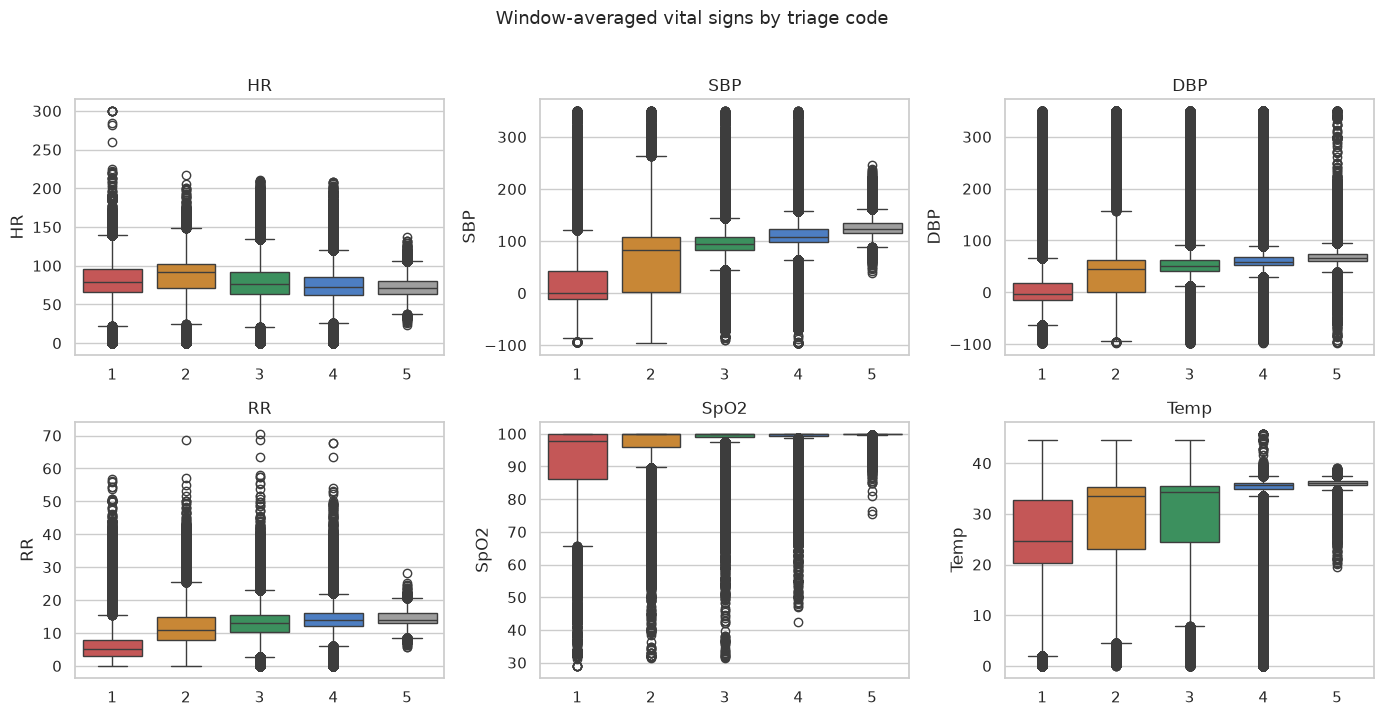

In [ ]:
# Window-averaged features (one value per window) — for standard box/correlation views
win_mean = X.mean(axis=1)                       
mean_df = pd.DataFrame(win_mean, columns=FEATURES)
mean_df['Code'] = [CODE_LABELS[i] for i in y]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, feat in zip(axes.ravel(), FEATURES):
    sns.boxplot(data=mean_df, x='Code', y=feat, hue='Code', palette=CODE_COLORS,
                legend=False, ax=ax, order=CODE_LABELS)
    ax.set_xticklabels([c.split(' - ')[0] for c in CODE_LABELS])
    ax.set_title(feat); ax.set_xlabel('')
plt.suptitle('Window-averaged vital signs by triage code', y=1.02, fontsize=13)
plt.tight_layout();
plt.show()

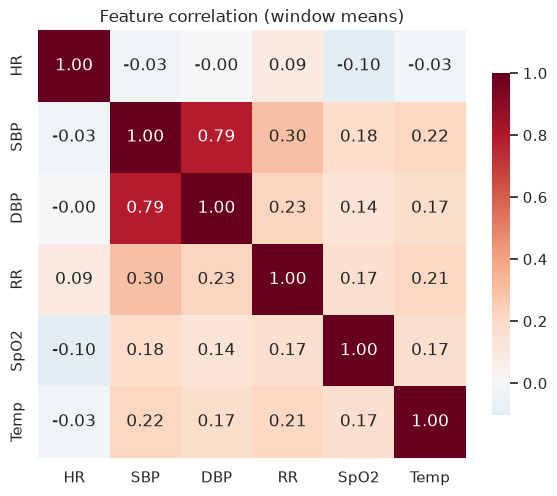

In [ ]:
# Correlation of window-averaged features
plt.figure(figsize=(6, 5))
sns.heatmap(mean_df[FEATURES].corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, cbar_kws={'shrink': 0.8})
plt.title('Feature correlation (window means)'); plt.tight_layout(); plt.show()

SBP and DBP have got an high value of correlation (around $79\%$). We chose to keeep both because they are equally important and the number of parameters is not too high.

## 4. Parameterized pipeline — one experiment per window size

For **each** window size the very same pipeline runs end-to-end:

1. **Windowing** with `stride = window // 2` (50% overlap).
2. **Feature extraction**: each window is collapsed into **5 statistics per vital** (mean, std, min, max, least-squares slope), giving a fixed **30-value** input vector regardless of the window length. This is what replaces the convolutions: emlearn converts fully-connected Keras models only (`eml_net`), so the temporal axis must be summarised by hand before the network. The slope is the one statistic carrying the *direction* of change, i.e. the information a NEWS2-style score on central values cannot see.
3. **Stratified split** 70 / 15 / 15 (keeps class ratios in every split — important because Code 1 is rare).
4. **Per-input standardization**: mean/std computed over the **training set only** (fitting on training data alone avoids leaking test statistics), per each of the 30 inputs rather than per vital — a slope and a maximum are not on comparable scales. Each window size gets **its own** constants, and the deployed firmware must hard-code the pair belonging to the chosen window.
5. **Model**: `Dense(32) → Dense(16) → Dense(5, softmax)`, the same shape as the course lab, widened at the input because the vector is 30 values rather than 3. Identical for every window size.
6. **Training** with early stopping on `val_loss` (and balanced class weights, if `USE_CLASS_WEIGHTS`).
7. **Evaluation *before* the Contiki translation** — the float Keras model on the held-out test set.
8. **Translation for Contiki** — `emlearn.convert()` emits a self-contained C99 header with float32 weights. No quantization is involved.
9. **Evaluation *after* the translation** — the generated C model run through emlearn's Python wrapper (the same C code the firmware compiles) on the **same** test set, plus Keras ↔ C agreement.

Because the windowing changes, each window size produces a different dataset **and** a different set of labels (the NEWS2 proxy is computed on the same window it labels). Accuracies across window sizes are therefore not strictly comparable: each is measured against its own version of the ground truth. The comparison is best read as *"over which horizon are the statistics most stable and most separable"*, together with the deployment cost in section 6.

In [ ]:
# --- Feature extraction: the window is summarized, not fed raw ---
#
# emlearn only converts fully-connected Keras models - eml_net supports Dense layers,
# not Conv1D. So the temporal axis has to be collapsed BEFORE the network,
# by hand, rather than by convolutions.
#
# Five statistics per vital, chosen so the firmware can compute them
# over its ring buffer in a few lines of C:
#   mean, std  - central tendency and dispersion (what NEWS2 scores)
#   min, max   - the extremes a median would hide
#   slope      - least-squares trend: the ONLY feature carrying the
#                direction of change, i.e. deterioration vs recovery.
#                NEWS2 on medians is blind to it, so this is what the
#                network can add on top of the scoring rule.
#
# The result is a fixed 30-value vector regardless of window size: the
# sweep then compares window lengths at constant architecture, and the
# firmware's input buffer never changes shape.

STAT_NAMES = ['mean', 'std', 'min', 'max', 'slope']
N_STATS    = len(STAT_NAMES)
N_INPUTS   = len(FEATURES) * N_STATS


# --- Timing/footprint implied by each window size (the firmware must match the chosen one) ---
timing = pd.DataFrame({
    'window (readings)'     : WINDOW_SIZES,
    'span (s of real time)' : [w * SAMPLING_INTERVAL for w in WINDOW_SIZES],
    'training stride'       : [max(1, w // 2) for w in WINDOW_SIZES],
    'ring buffer (B)'       : [w * len(FEATURES) * 4 for w in WINDOW_SIZES],
    'model input (B)'       : [N_INPUTS * 4] * len(WINDOW_SIZES),
}).set_index('window (readings)')

In [ ]:
def extract_features(X):
    """(n_windows, window, n_features) -> (n_windows, n_features * N_STATS).

    Layout is feature-major: [HR_mean, HR_std, ..., HR_slope, SBP_mean, ...]
    The firmware must build its input vector in this exact order.
    """
    window = X.shape[1]

    # Least-squares slope per (window, feature), computed in closed form:
    # slope = cov(t, x) / var(t), with t = 0..window-1. Cheaper and more
    # stable than np.polyfit over millions of windows.
    t = np.arange(window, dtype=np.float32)
    t_centered = t - t.mean()
    t_var = (t_centered ** 2).sum()

    mean = X.mean(axis=1)
    std = X.std(axis=1)
    mn = X.min(axis=1)
    mx = X.max(axis=1)
    slope = np.tensordot(X - mean[:, None, :], t_centered, axes=([1], [0])) / t_var

    # Stack as (n_windows, n_features, N_STATS) then flatten feature-major
    stacked = np.stack([mean, std, mn, mx, slope], axis=-1)
    return stacked.reshape(len(X), -1).astype(np.float32)


def build_model(window):
    """
    Same architecture for every window size: only the feature
    extractor sees the time axis, the network always gets N_INPUTS.

    Shape follows the course lab (Dense -> Dense -> softmax).
    """
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(N_INPUTS,)),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(len(CODE_LABELS), activation='softmax'),
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


build_model(BASELINE_WINDOW).summary()
print(f'\nInput vector: {len(FEATURES)} vitals x {N_STATS} stats = {N_INPUTS} values')


W0000 00:00:1788803300.278723    1881 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1788803300.573701    1881 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5233 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,605 (6.27 KB)

 Trainable params: 1,605 (6.27 KB)

 Non-trainable params: 0 (0.00 B)


Input vector: 6 vitals x 5 stats = 30 values


In [ ]:
def compute_metrics(y_true, y_pred):
    '''The headline indices: accuracy + macro precision/recall/F1 (imbalance-aware),
    plus the per-class breakdown — the recall on Code 1 (Red) is the safety-critical one.'''
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=range(len(CODE_LABELS)), zero_division=0)
    return {
        'accuracy'        : accuracy_score(y_true, y_pred),
        'prec_macro'      : prec.mean(),
        'recall_macro'    : rec.mean(),      # == balanced accuracy
        'f1_macro'        : f1.mean(),
        'recall_per_class': rec,
        'f1_per_class'    : f1,
        'report'          : classification_report(y_true, y_pred,
                                                  labels=range(len(CODE_LABELS)),
                                                  target_names=CODE_LABELS,
                                                  digits=3, zero_division=0),
    }

In [ ]:
# --- The Contiki translation: emlearn ---

import emlearn


def convert_emlearn(model, name):
    """Convert a Keras Sequential (Dense-only) model to a C header."""
    path = os.path.join('sweep_ckpt', f'{name}.h')
    cmodel = emlearn.convert(model, method='inline')
    cmodel.save(file=path, name=name)
    return path, cmodel


def emlearn_predict(cmodel, X_std):
    """Run the converted model the way the firmware will.

    emlearn's Python wrapper executes the SAME C code that gets compiled
    into the firmware, so this is a genuine pre-deployment check rather
    than a simulation of it."""
    return np.asarray(cmodel.predict(X_std), dtype=int)

In [ ]:
def run_window_experiment(window, series):
    '''Windowing -> feature extraction -> split -> standardize -> train
    -> Keras eval -> emlearn conversion -> emlearn eval.'''

    stride = max(1, window // 2)
    X_w, y_w = make_windows(series, window, stride)
    n_window = len(X_w)

    # Collapse the time axis HERE, before anything else.
    X_feat = extract_features(X_w)
    del X_w

    X_train, X_tmp, y_train, y_tmp = train_test_split(
        X_feat, y_w, test_size=0.30, stratify=y_w, random_state=SEED
    )
    del X_feat
    X_val, X_test, y_val, y_test = train_test_split(
        X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED
    )
    del X_tmp

    X_test_head = X_test[:15].copy()

    # Standardize per INPUT (30 of them), not per vital: each statistic
    # has its own scale (a slope and a max are not comparable).
    # feat_mean/feat_std must be hard-coded in the firmware - inference
    # on-device has to normalize exactly the same way.
    feat_mean, feat_std = X_train.mean(axis=0), X_train.std(axis=0)
    feat_std[feat_std == 0] = 1.0          # guard against a constant input
    std = lambda a: ((a - feat_mean) / feat_std).astype(np.float32)
    X_train, X_val, X_test = std(X_train), std(X_val), std(X_test)

    y_train_oh = tf.keras.utils.to_categorical(y_train, len(CODE_LABELS))
    y_val_oh   = tf.keras.utils.to_categorical(y_val,   len(CODE_LABELS))

    class_weight = None
    if USE_CLASS_WEIGHTS:
        present = np.unique(y_train)
        w = compute_class_weight('balanced', classes=present, y=y_train)
        class_weight = {int(c): float(v) for c, v in zip(present, w)}

    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)
    model = build_model(window)
    early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5,
                                             restore_best_weights=True, verbose=0)
    backup = tf.keras.callbacks.BackupAndRestore(
        backup_dir=os.path.join('sweep_ckpt', f'backup_w{window}'))

    hist = model.fit(X_train, y_train_oh,
                     validation_data=(X_val, y_val_oh),
                     epochs=200, batch_size=128,
                     class_weight=class_weight,
                     callbacks=[early, backup], verbose=1)

    # --- BEFORE the Contiki translation: float Keras model ---
    keras_pred = model.predict(X_test, verbose=0).argmax(axis=1)
    m_float = compute_metrics(y_test, keras_pred)

    # --- Translation for Contiki + AFTER: the generated C model ---
    header_path, cmodel = convert_emlearn(model, f'triage_w{window}')
    c_pred = emlearn_predict(cmodel, X_test)
    m_c = compute_metrics(y_test, c_pred)

    float_path = os.path.join('sweep_ckpt', f'float_w{window}.keras')
    model.save(float_path)

    return {
        'window': window, 'stride': stride,
        'n_windows': n_window, 'n_train': len(X_train), 'n_test': len(X_test),
        'epochs': len(hist.history['loss']),
        'history': {k: list(map(float, v)) for k, v in hist.history.items()},
        'feat_mean': feat_mean, 'feat_std': feat_std,
        'float': m_float, 'int8': m_c,          # key kept as 'int8' so
        'agreement': float((keras_pred == c_pred).mean()),  
        'y_test': y_test, 'keras_pred': keras_pred, 'int8_pred': c_pred,
        'X_test_head': X_test_head,
        'float_model_path': float_path,
        'int8_model_path':  header_path,
        'size_bytes': os.path.getsize(header_path),
        'quant': None,
    }

## 5. Run the sweep

One end-to-end experiment per window size.

In [ ]:
results = {}

CKPT_DIR = 'sweep_ckpt'
os.makedirs(CKPT_DIR, exist_ok=True)


for w in WINDOW_SIZES:

    ck = os.path.join(CKPT_DIR, f'window_{w}.pkl')
    if os.path.exists(ck):                       # Already done
        with open(ck, 'rb') as f:
            results[w] = pickle.load(f)
        print(f'=== window = {w}: loaded from checkpoint, skipping ===')
        continue

    print(f'=== window = {w} readings ({w * SAMPLING_INTERVAL} s) ===')
    r = run_window_experiment(w, series)
    results[w] = r
    
    with open(ck, 'wb') as f: #Save
        pickle.dump(r, f)

    print(f"  windows: {r['n_windows']:,}   epochs: {r['epochs']}   int8 model: {r['size_bytes']/1024:.1f} KB")
    print(f"  BEFORE (float): acc {r['float']['accuracy']*100:6.2f}%   macro-F1 {r['float']['f1_macro']*100:6.2f}%   Red recall {r['float']['recall_per_class'][0]*100:6.2f}%")
    print(f"  AFTER  (int8) : acc {r['int8']['accuracy']*100:6.2f}%   macro-F1 {r['int8']['f1_macro']*100:6.2f}%   Red recall {r['int8']['recall_per_class'][0]*100:6.2f}%   agreement {r['agreement']*100:.2f}%")
    print()

=== window = 10 readings (10 s) ===
Epoch 1/200


I0000 00:00:1788803346.012580    2701 service.cc:153] XLA service 0x73bde4003bb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1788803346.012632    2701 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5060 Laptop GPU, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1788803346.061138    2701 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1788803346.256683    2701 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1788803346.269113    2701 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1416__.17


   41/54271 ━━━━━━━━━━━━━━━━━━━━ 3:30 4ms/step - accuracy: 0.3639 - loss: 1.7332

I0000 00:00:1788803349.586005    2701 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


54265/54271 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8856 - loss: 0.3212

...

12311/12311 ━━━━━━━━━━━━━━━━━━━━ 53s 4ms/step - accuracy: 0.8355 - loss: 0.4652 - val_accuracy: 0.8705 - val_loss: 0.3031
Epoch 2/200
12311/12311 ━━━━━━━━━━━━━━━━━━━━ 46s 4ms/step - accuracy: 0.8796 - loss: 0.3256 - val_accuracy: 0.8880 - val_loss: 0.2673
Epoch 3/200
12311/12311 ━━━━━━━━━━━━━━━━━━━━ 45s 4ms/step - accuracy: 0.8918 - loss: 0.2929 - val_accuracy: 0.8989 - val_loss: 0.2445
Epoch 4/200
12311/12311 ━━━━━━━━━━━━━━━━━━━━ 45s 4ms/step - accuracy: 0.9033 - loss: 0.2671 - val_accuracy: 0.9116 - val_loss: 0.2184
Epoch 5/200
12311/12311 ━━━━━━━━━━━━━━━━━━━━ 46s 4ms/step - accuracy: 0.9159 - loss: 0.2437 - val_accuracy: 0.9218 - val_loss: 0.1971
Epoch 6/200
12311/12311 ━━━━━━━━━━━━━━━━━━━━ 45s 4ms/step - accuracy: 0.9237 - loss: 0.2277 - val_accuracy: 0.9284 - val_loss: 0.1813
Epoch 7/200
12311/12311 ━━━━━━━━━━━━━━━━━━━━ 45s 4ms/step - accuracy: 0.9290 - loss: 0.2170 - val_accuracy: 0.9341 - val_loss: 0.1696
Epoch 8/200
12311/12311 ━━━━━━━━━━━━━━━━━━━━ 46s 4ms/step - accuracy: 0.93

I0000 00:00:1788819062.639126    2701 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_21205885__.17


9014/9021 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8160 - loss: 0.5174

I0000 00:00:1788819096.075473    2699 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_21205885__.17
I0000 00:00:1788819097.335279   65081 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_22', 8 bytes spill stores, 8 bytes spill loads



9021/9021 ━━━━━━━━━━━━━━━━━━━━ 46s 5ms/step - accuracy: 0.8160 - loss: 0.5173 - val_accuracy: 0.8541 - val_loss: 0.3444
Epoch 2/200
9021/9021 ━━━━━━━━━━━━━━━━━━━━ 34s 4ms/step - accuracy: 0.8643 - loss: 0.3719 - val_accuracy: 0.8708 - val_loss: 0.3072
Epoch 3/200
9021/9021 ━━━━━━━━━━━━━━━━━━━━ 33s 4ms/step - accuracy: 0.8815 - loss: 0.3250 - val_accuracy: 0.8849 - val_loss: 0.2752
Epoch 4/200
9021/9021 ━━━━━━━━━━━━━━━━━━━━ 33s 4ms/step - accuracy: 0.8949 - loss: 0.2906 - val_accuracy: 0.8958 - val_loss: 0.2511
Epoch 5/200
9021/9021 ━━━━━━━━━━━━━━━━━━━━ 33s 4ms/step - accuracy: 0.9056 - loss: 0.2667 - val_accuracy: 0.9067 - val_loss: 0.2284
Epoch 6/200
9021/9021 ━━━━━━━━━━━━━━━━━━━━ 33s 4ms/step - accuracy: 0.9139 - loss: 0.2486 - val_accuracy: 0.9137 - val_loss: 0.2129
Epoch 7/200
9021/9021 ━━━━━━━━━━━━━━━━━━━━ 33s 4ms/step - accuracy: 0.9197 - loss: 0.2349 - val_accuracy: 0.9193 - val_loss: 0.2011
Epoch 8/200
9021/9021 ━━━━━━━━━━━━━━━━━━━━ 33s 4ms/step - accuracy: 0.9241 - loss: 0.224

## 6. Main indexes vs window size — before vs after the Contiki translation

**Before** = float Keras model; **after** = the C model generated by emlearn, which is what the nRF52840 executes.

- **Quality indexes** (with 5 imbalanced classes, macro-averages and the per-class view matter more than plain accuracy): accuracy, macro precision/recall/F1, and the **recall on Code 1 (Red)** — in triage a missed Red is the most costly error.
- **Deployment indexes**: generated header size, ring-buffer bytes on the device, window span (= time to the first prediction after boot).
- **Translation robustness**: Keras to C agreement. Since emlearn keeps float32 weights there is no quantization step, so this is expected to be ~100%: it verifies the conversion did not silently drop a layer, rather than measuring an accuracy/size trade-off.

In [ ]:
#Load saved state 
import pickle, glob, os

results = {}
for ck in sorted(glob.glob('sweep_ckpt/window_*.pkl')):
    with open(ck, 'rb') as f:
        r = pickle.load(f)
    results[r['window']] = r

print(f'Loaded {len(results)} window: {sorted(results.keys())}')

Loaded 5 window: [10, 20, 30, 45, 60]


In [ ]:
rows = []
for w in WINDOW_SIZES:
    r = results[w]
    f, q = r['float'], r['int8']
    rows.append({
        'window'          : w,
        'span (s)'        : w * SAMPLING_INTERVAL,
        '# windows'       : r['n_windows'],
        'acc float %'     : f['accuracy'] * 100,
        'acc int8 %'      : q['accuracy'] * 100,
        'Δacc (pp)'       : (q['accuracy'] - f['accuracy']) * 100,
        'F1m float %'     : f['f1_macro'] * 100,
        'F1m int8 %'      : q['f1_macro'] * 100,
        'ΔF1m (pp)'       : (q['f1_macro'] - f['f1_macro']) * 100,
        'Red rec float %' : f['recall_per_class'][0] * 100,
        'Red rec int8 %'  : q['recall_per_class'][0] * 100,
        'agree %'         : r['agreement'] * 100,
        'size KB'         : r['size_bytes'] / 1024,
        'buffer B'        : w * len(FEATURES),
    })

summary = pd.DataFrame(rows).set_index('window').round(2)
summary

,span (s),# windows,acc float %,acc int8 %,Δacc (pp),F1m float %,F1m int8 %,ΔF1m (pp),Red rec float %,Red rec int8 %,agree %,size KB,buffer B
window,,,,,,,,,,,,,
10,10,9923690,97.70,97.70,0.00,96.18,96.18,0.00,97.07,97.10,99.96,19.43,60
20,20,4959176,97.65,97.64,-0.01,96.30,96.30,-0.00,97.94,97.94,99.98,19.41,120
30,30,3304331,96.82,96.81,-0.01,94.60,94.59,-0.01,96.75,96.76,99.98,19.40,180
45,45,2251074,96.09,96.09,-0.00,93.64,93.64,-0.00,95.82,95.82,99.98,19.39,270
60,60,1649468,95.97,95.97,-0.00,93.37,93.36,-0.00,96.77,96.75,99.98,19.41,360


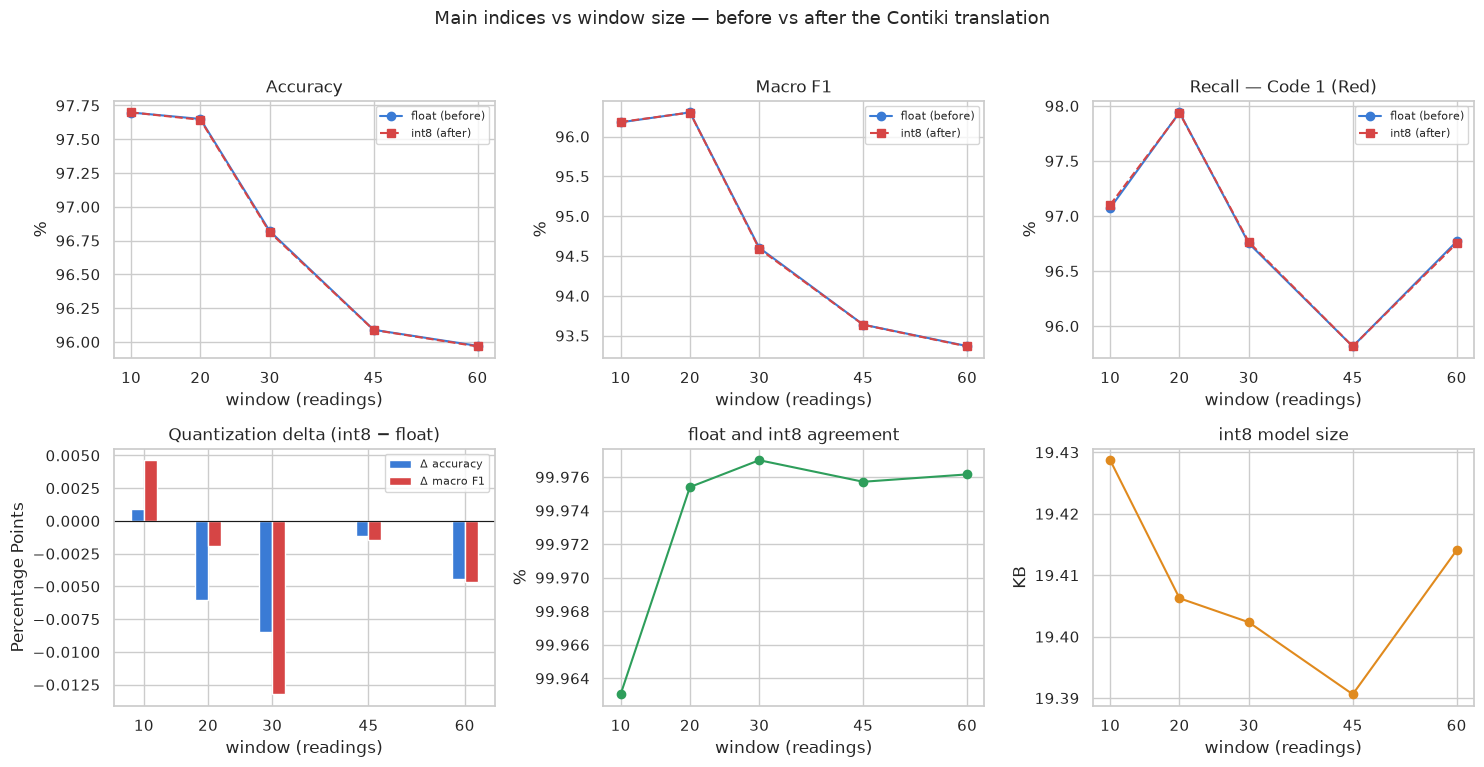

In [ ]:
ws    = WINDOW_SIZES
acc_f = [results[w]['float']['accuracy'] * 100 for w in ws]
acc_q = [results[w]['int8']['accuracy']  * 100 for w in ws]
f1_f  = [results[w]['float']['f1_macro'] * 100 for w in ws]
f1_q  = [results[w]['int8']['f1_macro']  * 100 for w in ws]
red_f = [results[w]['float']['recall_per_class'][0] * 100 for w in ws]
red_q = [results[w]['int8']['recall_per_class'][0]  * 100 for w in ws]
agree = [results[w]['agreement'] * 100 for w in ws]
sizek = [results[w]['size_bytes'] / 1024 for w in ws]
d_acc = [q - f for f, q in zip(acc_f, acc_q)]
d_f1  = [q - f for f, q in zip(f1_f,  f1_q)]

fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))

def duo(ax, yf, yq, title):
    ax.plot(ws, yf, 'o-',  color='#3a7bd5', label='float (before)')
    ax.plot(ws, yq, 's--', color='#d64545', label='int8 (after)')
    ax.set_title(title); ax.set_xlabel('window (readings)'); ax.set_ylabel('%')
    ax.set_xticks(ws); ax.legend(fontsize=8)

duo(axes[0, 0], acc_f, acc_q, 'Accuracy')
duo(axes[0, 1], f1_f,  f1_q,  'Macro F1')
duo(axes[0, 2], red_f, red_q, 'Recall — Code 1 (Red)')

ax = axes[1, 0]
ax.bar([w - 1 for w in ws], d_acc, width=2, color='#3a7bd5', label='Δ accuracy')
ax.bar([w + 1 for w in ws], d_f1,  width=2, color='#d64545', label='Δ macro F1')
ax.axhline(0, color='k', lw=0.8)
ax.set_title('Quantization delta (int8 − float)')
ax.set_xlabel('window (readings)');
ax.set_ylabel('Percentage Points')
ax.set_xticks(ws); ax.legend(fontsize=8)

ax = axes[1, 1]
ax.plot(ws, agree, 'o-', color='#2e9e5b')
ax.set_title('float and int8 agreement')
ax.set_xlabel('window (readings)'); ax.set_ylabel('%'); ax.set_xticks(ws)

ax = axes[1, 2]
ax.plot(ws, sizek, 'o-', color='#e08a1e')
ax.set_title('int8 model size')
ax.set_xlabel('window (readings)'); ax.set_ylabel('KB'); ax.set_xticks(ws)

plt.suptitle('Main indices vs window size — before vs after the Contiki translation',
             y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

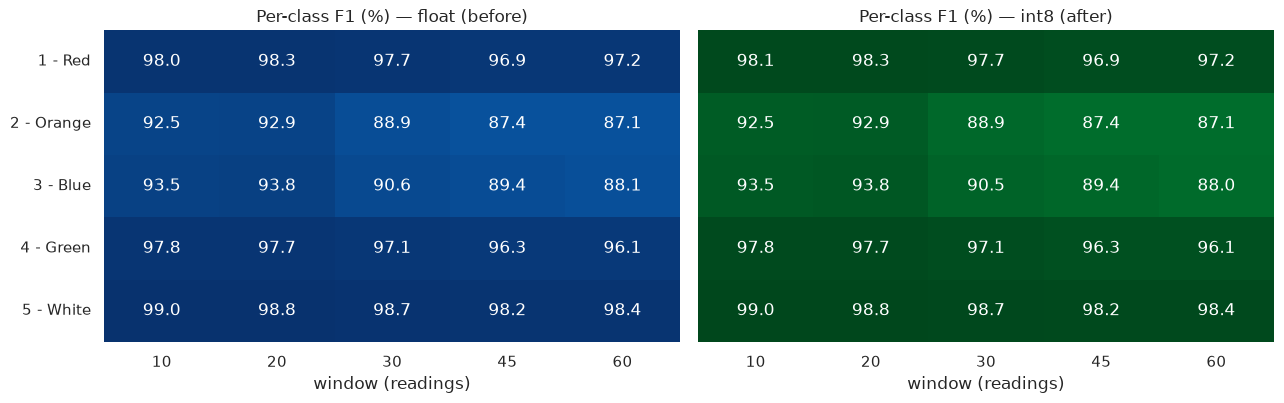

In [ ]:
# Per-class F1 across window sizes, before vs after the translation
f1_float = pd.DataFrame({w: results[w]['float']['f1_per_class'] * 100 for w in ws}, index=CODE_LABELS)
f1_int8  = pd.DataFrame({w: results[w]['int8']['f1_per_class']  * 100 for w in ws}, index=CODE_LABELS)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
sns.heatmap(f1_float, annot=True, fmt='.1f', cmap='Blues',  cbar=False, vmin=0, vmax=100, ax=a1)
a1.set_title('Per-class F1 (%) — float (before)'); a1.set_xlabel('window (readings)')
sns.heatmap(f1_int8,  annot=True, fmt='.1f', cmap='Greens', cbar=False, vmin=0, vmax=100, ax=a2)
a2.set_title('Per-class F1 (%) — int8 (after)');  a2.set_xlabel('window (readings)')
plt.tight_layout(); plt.show()

## 7. Deployment for Contiki-NG — emlearn (C99, float32)

The model is converted with emlearn which emits a self-contained C header: no runtime library, no C++, and therefore no friction with Contiki-NG's C build system.

Two constraints drove the architecture back in section 4:

- **emlearn's `eml_net` supports fully-connected layers only.** Conv1D is not implemented (open as an enhancement request upstream since 2019), so the temporal axis is collapsed by the hand-written feature extractor rather than by convolutions.
- **Weights stay float32.** There is no quantization step, so the C model reproduces the Keras model exactly (up to floating-point rounding). The "agreement" figure below is a conversion sanity check, not an accuracy/size trade-off.

In [ ]:
DEPLOY_WINDOW = 20
res = results[DEPLOY_WINDOW]

header_path = res['int8_model_path']
size_kb = res['size_bytes'] / 1024
NRF52840_RAM = 256 * 1024

print(f'Deployed window : {DEPLOY_WINDOW} readings '
      f'({DEPLOY_WINDOW * SAMPLING_INTERVAL}s of real time)')
print(f'Input vector    : {N_INPUTS} values ({len(FEATURES)} vitals x {N_STATS} stats)')
print(f'Generated header: {header_path}')
print(f'Size            : {size_kb:.1f} KB '
      f'({res["size_bytes"] / NRF52840_RAM * 100:.1f}% of the nRF52840 256 KB RAM)')
print(f'Keras/C agreement: {res["agreement"]*100:.2f}%')

# Ring buffer held by the firmware (vitals-buffer.c), separate from the
# 30-value model input: only this one grows with the window length.
ring_bytes = DEPLOY_WINDOW * len(FEATURES) * 4
print(f'Ring buffer     : {ring_bytes} B  '
      f'({ring_bytes/NRF52840_RAM*100:.2f}% of RAM)')
print(f'Model input     : {N_INPUTS * 4} B (fixed, independent of the window)')

# --- Constants the firmware must hard-code ---
#
# Inference on-device MUST standardize its inputs exactly as training
# did, otherwise the network sees a different scale and its output is
# meaningless. These belong to THIS window size only.
print('\n/* ---- paste into the patient firmware ---- */')
print(f'#define ML_WINDOW   {DEPLOY_WINDOW}')
print(f'#define ML_N_INPUTS {N_INPUTS}')
print('\nstatic const float FEATURE_MEAN[ML_N_INPUTS] = {')
print('  ' + ', '.join(f'{v:.6f}f' for v in res['feat_mean']))
print('};')
print('\nstatic const float FEATURE_SCALE[ML_N_INPUTS] = {')
print('  ' + ', '.join(f'{v:.6f}f' for v in res['feat_std']))
print('};')

# Input ordering, so the firmware builds its vector the right way round.
print('\n/* Input vector layout (feature-major): */')
for fi, feat in enumerate(FEATURES):
    for si, stat in enumerate(STAT_NAMES):
        print(f'/*  [{fi * N_STATS + si:2d}] {feat}_{stat} */')

Deployed window : 20 readings (20s of real time)
Input vector    : 30 values (6 vitals x 5 stats)
Generated header: sweep_ckpt/triage_w20.h
Size            : 19.4 KB (7.6% of the nRF52840 256 KB RAM)
Keras/C agreement: 99.98%
Ring buffer     : 480 B  (0.18% of RAM)
Model input     : 120 B (fixed, independent of the window)

/* ---- paste into the patient firmware ---- */
#define ML_WINDOW   20
#define ML_N_INPUTS 30

static const float FEATURE_MEAN[ML_N_INPUTS] = {
  74.387909f, 1.324344f, 72.650040f, 76.525810f, 0.000353f, 109.649620f, 2.409699f, 105.997200f, 113.496552f, 0.003130f, 59.236668f, 1.751063f, 56.425270f, 61.812954f, 0.001647f, 13.674246f, 0.078965f, 13.565016f, 13.785368f, 0.000347f, 96.314041f, 0.109620f, 96.241760f, 96.357643f, -0.000546f, 33.501007f, 0.018429f, 33.469517f, 33.528313f, 0.000139f
};

static const float FEATURE_SCALE[ML_N_INPUTS] = {
  17.021902f, 2.786590f, 16.764019f, 18.377077f, 0.354184f, 39.519066f, 5.465877f, 39.858753f, 40.525295f, 0.717942f, 29.22

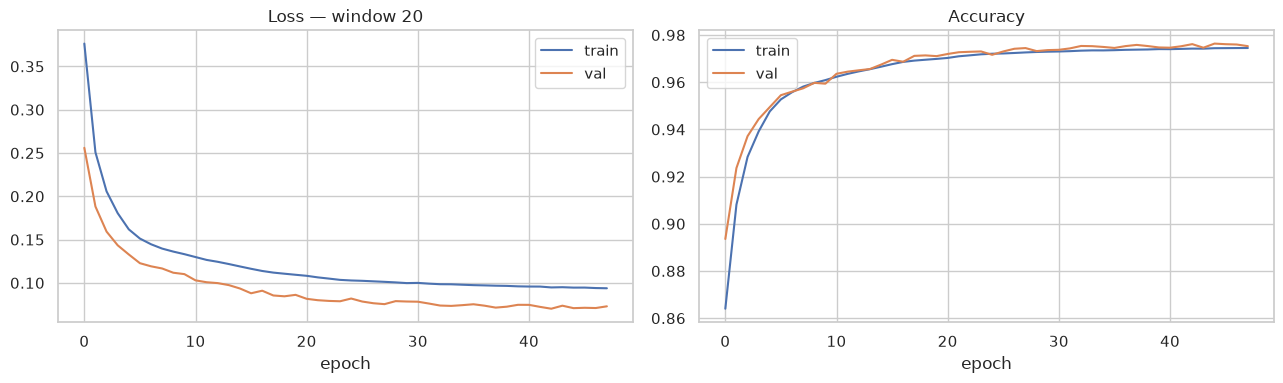

In [ ]:
# Training curves of the deployed window (sanity check on convergence / overfitting)
h = res['history']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(h['loss'], label='train')
ax1.plot(h['val_loss'], label='val')
ax1.set_title(f'Loss — window {DEPLOY_WINDOW}')
ax1.set_xlabel('epoch')
ax1.legend()
ax2.plot(h['accuracy'], label='train')
ax2.plot(h['val_accuracy'], label='val')
ax2.set_title('Accuracy')
ax2.set_xlabel('epoch')
ax2.legend()
plt.tight_layout();
plt.show()

## 8. Validation of the deployed model

Last check on the chosen window, in full detail: the generated C model must track the float model closely (before vs after the translation, here expected to be near-exact, since no quantization is involved), and the confusion matrixes must stay near-diagonal. With 5 imbalanced classes, per-class precision/recall/F1 matter more than overall accuracy.

In [ ]:
y_test     = res['y_test']
keras_pred = res['keras_pred']
int8_pred  = res['int8_pred']

keras_acc  = accuracy_score(y_test, keras_pred) * 100
int8_acc   = accuracy_score(y_test, int8_pred) * 100
agreement  = (keras_pred == int8_pred).mean() * 100
n_disagree = int((keras_pred != int8_pred).sum())

print(f'Deployed window         : {DEPLOY_WINDOW} readings = {DEPLOY_WINDOW * SAMPLING_INTERVAL} s')
print(f'Test windows            : {len(y_test)}')
print(f'Keras (float) accuracy  : {keras_acc:.3f}%')
print(f'TFLite (int8) accuracy  : {int8_acc:.3f}%')
print(f'Quantization delta      : {int8_acc - keras_acc:+.3f} pp')
print(f'Keras vs int8 agreement : {agreement:.3f}%')
print(f'Disagreements           : {n_disagree} / {len(y_test)}')

print('\n--- BEFORE the translation: float Keras model ---')
print(res['float']['report'])
print('--- AFTER the translation: int8 TFLite model ---')
print(res['int8']['report'])

Deployed window         : 20 readings = 20 s
Test windows            : 743877
Keras (float) accuracy  : 97.650%
TFLite (int8) accuracy  : 97.644%
Quantization delta      : -0.006 pp
Keras vs int8 agreement : 99.975%
Disagreements           : 183 / 743877

--- BEFORE the translation: float Keras model ---
              precision    recall  f1-score   support

     1 - Red      0.986     0.979     0.983     36917
  2 - Orange      0.908     0.950     0.929     27162
    3 - Blue      0.918     0.959     0.938     71445
   4 - Green      0.987     0.967     0.977    299295
   5 - White      0.985     0.991     0.988    309058

    accuracy                          0.977    743877
   macro avg      0.957     0.969     0.963    743877
weighted avg      0.977     0.977     0.977    743877

--- AFTER the translation: int8 TFLite model ---
              precision    recall  f1-score   support

     1 - Red      0.986     0.979     0.983     36917
  2 - Orange      0.909     0.950     0.929    

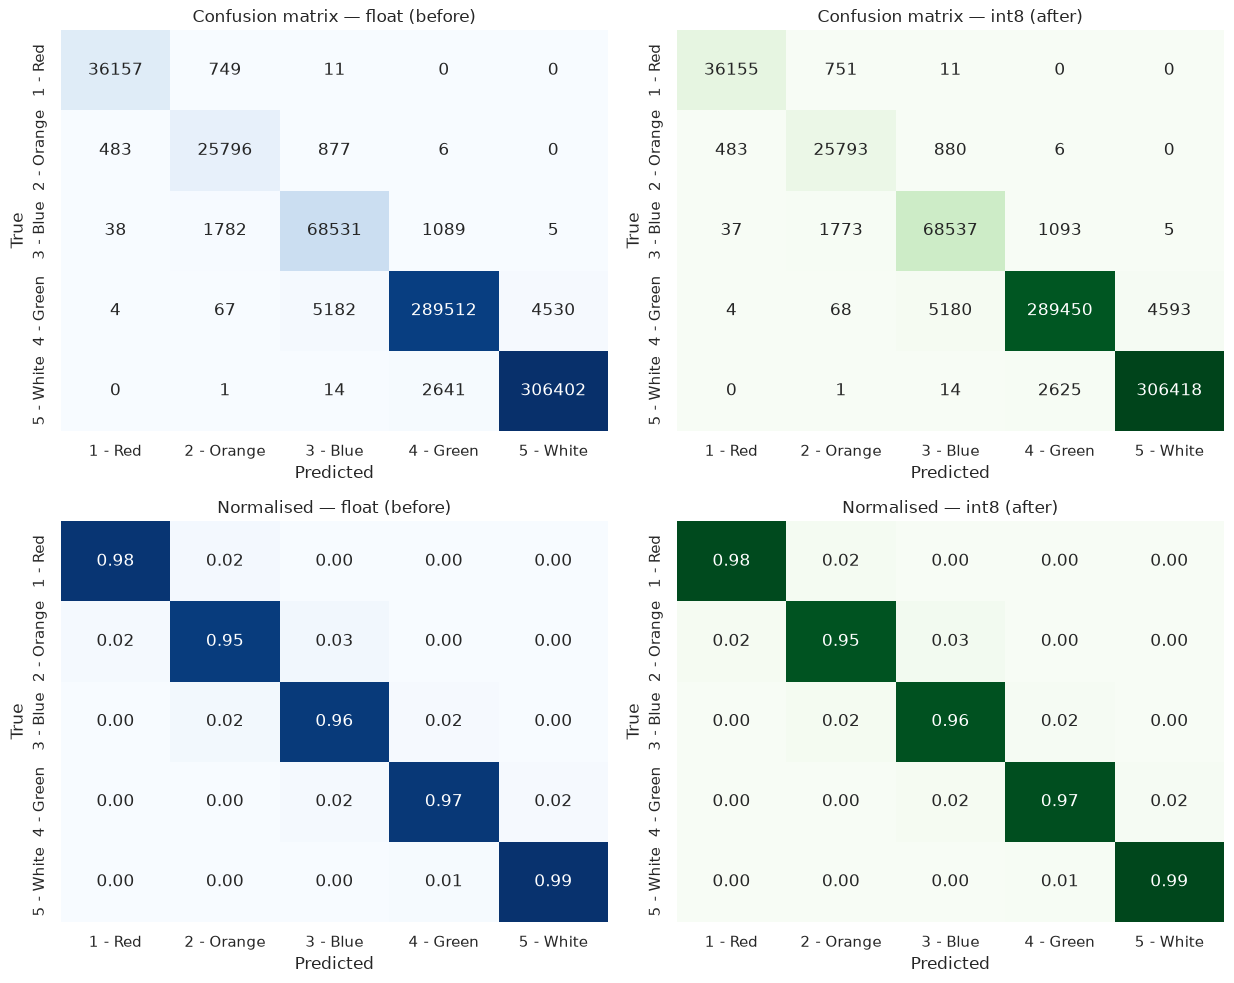

In [ ]:
fig, axes2 = plt.subplots(2, 2, figsize=(12.5, 10))

for col, (pred, name, cmapc) in enumerate([
        (keras_pred, 'float (before)', 'Blues'),
        (int8_pred,  'int8 (after)',   'Greens')]):

    cm = confusion_matrix(y_test, pred, labels=range(len(CODE_LABELS)))

    # Row-normalized
    with np.errstate(divide='ignore', invalid='ignore'):
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    cm_norm = np.nan_to_num(cm_norm)

    # Top row: absolute counts
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmapc,
                xticklabels=CODE_LABELS, yticklabels=CODE_LABELS,
                cbar=False, ax=axes2[0, col])
    axes2[0, col].set_xlabel('Predicted'); axes2[0, col].set_ylabel('True')
    axes2[0, col].set_title(f'Confusion matrix — {name}')

    # Bottom row: same data, row-normalized
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap=cmapc, vmin=0, vmax=1,
                xticklabels=CODE_LABELS, yticklabels=CODE_LABELS,
                cbar=False, ax=axes2[1, col])
    axes2[1, col].set_xlabel('Predicted'); axes2[1, col].set_ylabel('True')
    axes2[1, col].set_title(f'Normalised — {name}')

plt.tight_layout(); plt.show()

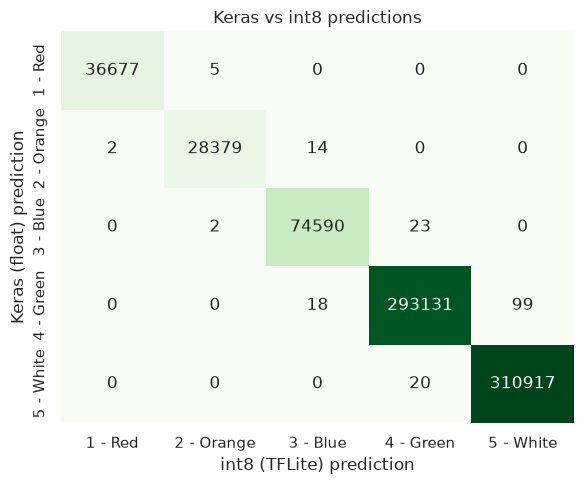

Accuracy retained : 97.64% vs 97.65% (drop +0.01 pp)
Disagreements     : 183  ->  adjacent-code: 183, multi-code jump: 0


In [ ]:
# Keras-vs-int8 confusion: near-diagonal means the quantized model tracks the float model.
cm_ki = confusion_matrix(keras_pred, int8_pred, labels=range(len(CODE_LABELS)))
plt.figure(figsize=(6, 5))
sns.heatmap(cm_ki, annot=True, fmt='d', cmap='Greens',
            xticklabels=CODE_LABELS, yticklabels=CODE_LABELS, cbar=False)
plt.xlabel('int8 (TFLite) prediction'); plt.ylabel('Keras (float) prediction')
plt.title('Keras vs int8 predictions')
plt.tight_layout(); plt.show()

diff_mask = keras_pred != int8_pred
adj_flips = int((np.abs(keras_pred - int8_pred) == 1).sum())
far_flips = int((np.abs(keras_pred - int8_pred) >= 2).sum())
acc_drop  = keras_acc - int8_acc          # positive => int8 is worse

print(f'Accuracy retained : {int8_acc:.2f}% vs {keras_acc:.2f}% (drop {acc_drop:+.2f} pp)')
print(f'Disagreements     : {int(diff_mask.sum())}  ->  adjacent-code: {adj_flips}, '
      f'multi-code jump: {far_flips}')

# Estimate the on-device simulator parameters (baseline / noise_amp / pull_pct)

The firmware fakes vitals with a mean-reverting AR(1) step:
$$
    next = current + (baseline - current) * pull\_pct/100 + noise
$$
Rather than eye-picking those three numbers, they are derived from VitalDB.

In [ ]:
# BASELINES

# Pooled across all cases. The MEDIAN is used rather than the mean: it is
# robust to whatever junk survives the mask, and it is the value a "typical"
# patient sits at.
all_rows = pd.DataFrame(np.vstack(series), columns=FEATURES)

baseline = all_rows.median()

# Step-to-step noise and persistence

# noise_amp and pull_pct describe how ONE patient moves between TWO CONSECUTIVE
# readings, not how patients differ from each other. So both are computed
# per case and then pooled, never on the flattened population:
#
#   noise_amp : std of the first differences (how big a single step is)
#   phi       : lag-1 autocorrelation (how much a reading remembers the previous)
#
# Cases are masked individually so that a gap does not create a fake jump
# between the values on either side of it.
diff_chunks, phi_rows = [], []

for s_arr in series:
    df_case = pd.DataFrame(s_arr, columns=FEATURES)
    diff_chunks.append(np.diff(df_case.to_numpy(), axis=0))
    phi_rows.append([df_case[f].autocorr(lag=1) for f in FEATURES])

diffs = pd.DataFrame(np.vstack(diff_chunks), columns=FEATURES)
noise_std = diffs.std()

phi = pd.Series(np.nanmean(np.asarray(phi_rows, dtype=float), axis=0), index=FEATURES)
pull_pct = ((1 - phi) * 100).clip(lower=0, upper=100)

# summary
params = pd.DataFrame({
    'baseline'        : baseline.round(2),
    'noise_std'       : noise_std.round(3),                 # use directly with gaussian noise
    'noise_amp_unif'  : (noise_std * np.sqrt(3)).round(3),  # equivalent uniform half-width, needed for the uniform generation
    'phi_lag1'        : phi.round(4),
    'pull_pct'        : pull_pct.round(1),
})

print(f'\nEstimated at the cached sampling interval of {SAMPLING_INTERVAL}s '
      '- the firmware must publish at this same interval for these numbers to hold.')
print(params)


Estimated at the cached sampling interval of 1s - the firmware must publish at this same interval for these numbers to hold.
        baseline  noise_std  noise_amp_unif  phi_lag1  pull_pct
HR     72.000000      1.889           3.271    0.9866       1.3
SBP   115.000000      3.969           6.874    0.9935       0.6
DBP    61.000000      3.653           6.328    0.9887       1.1
RR     14.000000      0.267           0.462    0.9973       0.3
SpO2  100.000000      0.289           0.500    0.9883       1.2
Temp   35.700001      0.172           0.298    0.9973       0.3
